In [7]:
from distmesh import *
import numpy as np
import matplotlib.pyplot as plt
import scipy


In [2]:
def mesh_gen():
    n = 60
    t = np.linspace(0,2*np.pi*(n/(n+1)),n)
    rad = 1.0
    h0 = 0.1# the desired side of mesh triangles

    pfix = np.concatenate((np.reshape(rad*np.cos(t),(n,1)),np.reshape(rad*np.sin(t),(n,1))),axis = 1)
    pfix[:,0] = pfix[:,0] + 1.5 
    pfix[:,1] = pfix[:,1] + 1.5
    # indexes of angle values for defining ears
    f = lambda p: drectangle(p, 0, 3, 0, 3)
    fh = huniform

    bbox = [0,3,0,3] # the bounding box

    pts,tri = distmesh2D(f,fh,h0,bbox,pfix)
    return pts, tri, pfix

In [3]:
def stima3(verts):
    Aux = np.ones((3,3))
    Aux[1:3,:] = np.transpose(verts)
    rhs = np.zeros((3,2))
    rhs[1,0] = 1
    rhs[2,1] = 1
    G = np.zeros((3,2))
    G[:,0] = np.linalg.solve(Aux,rhs[:,0])
    G[:,1] = np.linalg.solve(Aux,rhs[:,1])
    M = 0.5*np.linalg.det(Aux)*np.matmul(G,np.transpose(G))
    return M

def FEM(pts, tri, d_bdry, idx_x0, idx_x1, a1=1.2, a2=1):
    Npts = np.size(pts,axis=0) # the number of mesh points
    Ntri = np.size(tri,axis=0) # the number of triangle

    free_nodes = np.setdiff1d(np.arange(0,Npts,1,dtype = int),d_bdry,assume_unique=True)

    A = scipy.sparse.csr_matrix((Npts,Npts), dtype = float).toarray() # define the sparse matrix A
    b = np.zeros((Npts,1)) # the right-hand side
    u = np.zeros((Npts,1)) # the solution
    u[idx_x1] = 1 # define u at known values
    u[idx_x0] = 0

    # stiffness matrix
    a_c = 1
    for j in range(Ntri):
        v = pts[tri[j,:],:] # vertices of mesh triangle
        centroid = np.mean(v, axis=0)
        if (centroid[0] - 1.5)**2 + (centroid[1] - 1.5)**2 < 1: 
            a_c = a1
        else: 
            a_c = a2
        ind = tri[j,:]
        indt = np.array(ind)[:,None]
        A[np.ix_(ind, ind)] += a_c * stima3(v)
        #A[indt,ind] = A[indt,ind] + a_c*stima3(v)

    # load vector
    b = b - np.matmul(A,u)

    free_nodes_t = np.array(free_nodes)[:,None]
    u[free_nodes] = scipy.linalg.solve(A[free_nodes_t,free_nodes],b[free_nodes])
    u = np.reshape(u,(Npts,))
    return u

In [18]:
def grad(pts, tri, u, a1=1.2, a2=1): 
    Ntris = tri.shape[0] 
    Npts = pts.shape[0] 
    A = np.array([[0, 1, 0], [0, 0, 1]])
    num_tri = len(tri)
    grad_x_elements = np.zeros(num_tri)
    grad_y_elements = np.zeros(num_tri)

    a_c = 1
    for i, tr in enumerate(tri):
        coords = pts[tr]
        u_tri = u[tr] 
        centroid = np.mean(coords, axis=0)
        if (centroid[0] - 1.5)**2 + (centroid[1] - 1.5)**2 < 1: 
            a_c = a1
        else: 
            a_c = a2

        # Compute gradient
        M = np.column_stack([np.ones(3), coords])
        grad = A @ np.linalg.solve(M, u_tri)

        grad_x_elements[i] = -1*a_c*grad[0]
        grad_y_elements[i] = -1*a_c*grad[1]
        
    return grad_x_elements, grad_y_elements

def get_node_grad(pts, tri, grad_x_e, grad_y_e):
    num_pts = len(pts)
    grad_x_nodes = np.zeros(num_pts)
    grad_y_nodes = np.zeros(num_pts)
    count = np.zeros(num_pts)

    for i, tr in enumerate(tri):
        # Add the triangle's constant gradient to each of its 3 nodes
        for node_idx in tr:
            grad_x_nodes[node_idx] += grad_x_e[i]
            grad_y_nodes[node_idx] += grad_y_e[i]
            count[node_idx] += 1

    safe_count = np.where(count > 0, count, 1)
    return grad_x_nodes/safe_count, grad_y_nodes/safe_count

In [ ]:
pts, tri, pfix = mesh_gen()
idx_x0 = np.where(np.isclose(pts[:, 0], 0, atol=1e-6))[0]
idx_x1 = np.where(np.isclose(pts[:, 0], 3, atol=1e-6))[0]

d_bdry = np.concatenate((idx_x0, idx_x1))
plt.scatter(pts[:,0], pts[:,1], color='blue')
plt.scatter(pts[d_bdry, 0], pts[d_bdry, 1], color='red')

plt.savefig('grid point')

count =  200 displacement =  0.007247689953511012
count =  400 displacement =  0.004285231322468837
count =  600 displacement =  0.006260781135147564
count =  800 displacement =  0.0034675585803712458
count =  1000 displacement =  0.005600990615950189
count =  1200 displacement =  0.007694230101900405
count =  1400 displacement =  0.007132109056699065
count =  1600 displacement =  0.0076637107158742095
count =  1800 displacement =  0.007605914643128432
count =  2000 displacement =  0.007354294978073285
count =  2200 displacement =  0.0068482772200435735
count =  2400 displacement =  0.006285523797367025
count =  2600 displacement =  0.00584429406264396
count =  2800 displacement =  0.005537737851054404
count =  3000 displacement =  0.005330959724298816
count =  3200 displacement =  0.0051899334879260016
count =  3400 displacement =  0.005095298124382352
count =  3600 displacement =  0.005029399422919435
count =  3800 displacement =  0.004982569094313318
count =  4000 displacement =  0.

TypeError: scatter() missing 1 required positional argument: 'y'

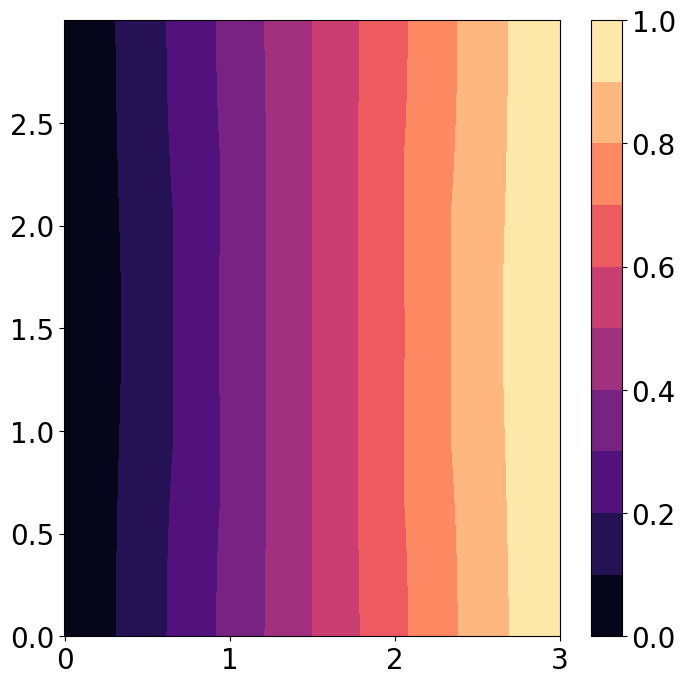

In [27]:
#Solves for gradient
idx_x0 = np.where(np.isclose(pts[:, 0], 0, atol=1e-6))[0]
idx_x1 = np.where(np.isclose(pts[:, 0], 3, atol=1e-6))[0]

d_bdry = np.concatenate((idx_x0, idx_x1))

u = FEM(pts, tri, d_bdry, idx_x0, idx_x1, a1=0.8, a2=1)

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize = (8,8))
plt.tricontourf(pts[:,0], pts[:,1],tri,u,np.arange(0,1.1,0.1), cmap='magma')
plt.colorbar()
plt.savefig('res08.png')

0.4321895637418958 0.26021263273369694


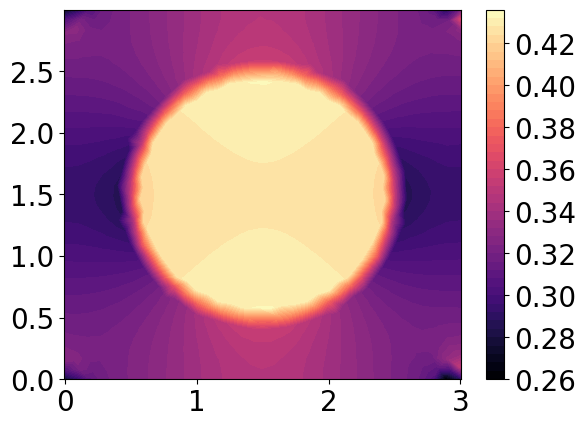

In [29]:
gx, gy = grad(pts, tri, u)

#du = np.sqrt(gx**2 + gy**2)
# plt.tripcolor(pts[:,0], pts[:,1], tri, du, cmap='viridis')
# plt.colorbar()
# plt.show()

#print(gx, gy)
fx, fy = get_node_grad(pts, tri, gx, gy)

mag = np.sqrt(fx**2 + fy**2)
print(np.max(mag), np.min(mag))
plt.tricontourf(pts[:,0], pts[:,1], tri, mag, 50, cmap='magma')
plt.colorbar()
plt.savefig('grad08.png')

